# DS317.R11 – Kiểm chứng chất lượng và thời gian của dữ liệu

Số liệu cho ô Chất lượng, ô Thời gian (bảng 1.2) và phần chia tập (bảng 4.1) của bản đề xuất.

1. Dòng trùng
2. Giá trị thiếu
3. Giá trị mâu thuẫn
4. Thời gian và tập test 2022
5. Bảng inventory
6. SKU giá dưới 100
7. Đơn vị tiền tệ
8. Tóm tắt

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 160)

from pathlib import Path
# Tự tìm thư mục gốc repo (chứa data/raw). Máy khác/Colab: đặt biến môi trường DS317_DATA_DIR.
_ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'data' / 'raw').is_dir()), None)
DATA_DIR = os.environ.get('DS317_DATA_DIR') or (str(_ROOT / 'data' / 'raw' / 'datathon-2026-round-1') if _ROOT else '/content/sample_data')

DATE_COLS = {
    'customers': ['signup_date'], 'inventory': ['snapshot_date'], 'orders': ['order_date'],
    'promotions': ['start_date', 'end_date'], 'returns': ['return_date'], 'reviews': ['review_date'],
    'sales': ['Date'], 'shipments': ['ship_date', 'delivery_date'], 'web_traffic': ['date'],
}
TABLES = ['customers', 'geography', 'inventory', 'orders', 'order_items', 'payments', 'products',
          'promotions', 'returns', 'reviews', 'sales', 'shipments', 'web_traffic']

dfs = {t: pd.read_csv(os.path.join(DATA_DIR, f'{t}.csv'), parse_dates=DATE_COLS.get(t, []),
                      dtype={'promo_id': 'string', 'promo_id_2': 'string'})
       for t in TABLES}

orders, oi, prod, inv, s = dfs['orders'], dfs['order_items'], dfs['products'], dfs['inventory'], dfs['sales']
s = s.set_index('Date').sort_index()

pd.DataFrame({t: {'rows': len(d), 'cols': d.shape[1]} for t, d in dfs.items()}).T

,rows,cols
customers,121930,7
geography,39948,4
inventory,60247,17
orders,646945,8
order_items,714669,7
payments,646945,4
products,2412,8
promotions,50,10
returns,39939,7
reviews,113551,7


`sample_submission.csv` là file nộp bài của cuộc thi nên không đọc. `promotions` có 50 dòng (đếm bằng `wc -l` ra 49 vì dòng cuối không có ký tự xuống dòng).

## 1. Dòng trùng (ô Chất lượng)

Kiểm tra trùng nguyên dòng và trùng theo khóa của từng bảng.

In [2]:
KEYS = {
    'customers': ['customer_id'], 'geography': ['zip'], 'inventory': ['product_id', 'snapshot_date'],
    'orders': ['order_id'], 'order_items': ['order_id', 'product_id'], 'payments': ['order_id'],
    'products': ['product_id'], 'promotions': ['promo_id'], 'returns': ['return_id'],
    'reviews': ['review_id'], 'sales': ['Date'], 'shipments': ['order_id'], 'web_traffic': ['date'],
}
dup = pd.DataFrame([{'table': t, 'key': ', '.join(k), 'rows': len(dfs[t]),
                     'dup_full_row': dfs[t].duplicated().sum(), 'dup_key': dfs[t].duplicated(k).sum()}
                    for t, k in KEYS.items()])
display(dup)
oi[oi.duplicated(['order_id', 'product_id'], keep=False)].sort_values(['order_id', 'product_id']).head(6)

,table,key,rows,dup_full_row,dup_key
0,customers,customer_id,121930,0,0
1,geography,zip,39948,0,0
2,inventory,"product_id, snapshot_date",60247,0,0
3,orders,order_id,646945,0,0
4,order_items,"order_id, product_id",714669,0,16
5,payments,order_id,646945,0,0
6,products,product_id,2412,0,0
7,promotions,promo_id,50,0,0
8,returns,return_id,39939,0,0
9,reviews,review_id,113551,0,0


,order_id,product_id,quantity,unit_price,discount_amount,promo_id,promo_id_2
12233,14280,976,1,4019.47,0.0,<NA>,<NA>
12234,14280,976,2,3937.99,0.0,<NA>,<NA>
99645,113379,786,6,694.34,0.0,<NA>,<NA>
99646,113379,786,1,699.37,0.0,<NA>,<NA>
189239,215525,1859,5,1896.11,0.0,<NA>,<NA>
189240,215525,1859,5,1897.20,0.0,<NA>,<NA>


**Nhận xét**

- Không bảng nào có dòng trùng nguyên dòng.
- `order_items` có 16 dòng (8 cặp) trùng `(order_id, product_id)` nhưng khác `quantity` và `unit_price`. Đây là hai dòng hàng riêng của cùng một SKU trong một đơn, không phải nhập trùng, nên giữ nguyên.
- Mỗi dòng của `order_items` là "1 dòng hàng trong 1 đơn", không hẳn là "1 SKU trong 1 đơn".

## 2. Giá trị thiếu (ô Chất lượng, phụ lục)

Tách ba kiểu thiếu:

- ô rỗng (và xem ô rỗng đó có nghĩa là "không áp dụng" hay không);
- thiếu nguyên dòng ở các bảng theo ngày;
- bản ghi con bị thiếu.

In [3]:
STRUCTURAL = {('order_items', 'promo_id'), ('order_items', 'promo_id_2'), ('promotions', 'applicable_category')}
missing = pd.DataFrame([{'table': t, 'column': c, 'n_null': d[c].isna().sum(),
                         'pct_null': round(d[c].isna().mean() * 100, 2),
                         'loai': 'không áp dụng' if (t, c) in STRUCTURAL else 'thiếu thật'}
                        for t, d in dfs.items() for c in d.columns if d[c].isna().any()])
print('Tổng số cột:', sum(d.shape[1] for d in dfs.values()), '| số cột có ô rỗng:', len(missing))
display(missing)

# giá trị giả dạng thiếu: chuỗi rỗng, 'unknown', ...
FAKE_NA = {'', 'unknown', 'none', 'null', 'nan', 'n/a', '-', '?'}
fake = [(t, c) for t, d in dfs.items() for c in d.select_dtypes(include=['object', 'string']).columns
        if d[c].dropna().astype(str).str.strip().str.lower().isin(FAKE_NA).any()]
print('Cột chứa chuỗi kiểu unknown/rỗng:', fake or 'không có')

# thiếu nguyên dòng, lấy khoảng ngày của sales làm chuẩn
full_days = pd.date_range(s.index.min(), s.index.max(), freq='D')
for t, col in [('sales', 'Date'), ('web_traffic', 'date')]:
    miss = full_days.difference(dfs[t][col])
    print(f'{t}: thiếu {len(miss)} ngày', f'({miss.min().date()} → {miss.max().date()})' if len(miss) else '')

Tổng số cột: 93 | số cột có ô rỗng: 3


,table,column,n_null,pct_null,loai
0,order_items,promo_id,438353,61.34,không áp dụng
1,order_items,promo_id_2,714463,99.97,không áp dụng
2,promotions,applicable_category,40,80.00,không áp dụng


Cột chứa chuỗi kiểu unknown/rỗng: không có
sales: thiếu 0 ngày 
web_traffic: thiếu 181 ngày (2012-07-04 → 2012-12-31)


In [4]:
# bản ghi con bị thiếu
has_ship = orders['order_id'].isin(dfs['shipments']['order_id']).rename('co_van_don')
display(pd.crosstab(orders['order_status'], has_ship, margins=True))

inv_sorted = inv.sort_values(['product_id', 'snapshot_date'])
gap = inv_sorted.groupby('product_id')['snapshot_date'].diff().dt.days
print('SKU trong products:', prod['product_id'].nunique(), '| SKU có trong inventory:', inv['product_id'].nunique())
print('SKU bị hổng ít nhất một tháng snapshot:', (gap > 31).groupby(inv_sorted['product_id']).any().sum())

co_van_don,False,True,All
order_status,,,
cancelled,59462,0,59462
created,7275,0,7275
delivered,524,516192,516716
paid,13577,0,13577
returned,29,36113,36142
shipped,11,13762,13773
All,80878,566067,646945


SKU trong products: 2412 | SKU có trong inventory: 1624
SKU bị hổng ít nhất một tháng snapshot: 1302


**Nhận xét**

- Chỉ 3/93 cột có ô rỗng, và cả 3 đều mang nghĩa "không áp dụng": `promo_id` (61,34%), `promo_id_2` (99,97%), `promotions.applicable_category` (80%). Không cần điền giá trị; khi làm đặc trưng thì đổi thành cờ có/không khuyến mãi.
- Không có chuỗi giả dạng thiếu. Các giá trị 0 ở `stockout_days`, `discount_amount`, `shipping_fee` đều là giá trị hợp lệ.
- Các chỗ thiếu thật:
  - `web_traffic` thiếu 181 ngày **nửa cuối 2012** (04/07–31/12/2012).
  - 564 đơn đã gửi hàng (delivered 524, returned 29, shipped 11) không có vận đơn. Đơn cancelled, created, paid không có vận đơn là đúng logic.
  - `inventory` chỉ phủ 1.624/2.412 SKU; 1.302 SKU bị hổng tháng.

## 3. Giá trị mâu thuẫn (ô Chất lượng, phụ lục)

Mỗi luật đếm số dòng vi phạm trên tổng số dòng được kiểm tra. Luật nào ra 0 vẫn giữ lại trong bảng.

In [5]:
o = orders[['order_id', 'order_date', 'customer_id', 'order_status']]
sh = dfs['shipments'].merge(o, on='order_id')
rt = dfs['returns'].merge(o, on='order_id')
rv = dfs['reviews'].merge(o, on='order_id', suffixes=('', '_order'))
oi_p = oi.merge(prod[['product_id', 'price', 'cogs']], on='product_id')
rt = rt.join(oi.groupby(['order_id', 'product_id'])['quantity'].sum().rename('qty_bought'), on=['order_id', 'product_id'])
o_c = o.merge(dfs['customers'][['customer_id', 'signup_date']], on='customer_id')
order_total = (oi_p['quantity'] * oi_p['unit_price'] - oi_p['discount_amount']).groupby(oi_p['order_id']).sum()
pay = dfs['payments'].set_index('order_id').join(order_total.rename('items_total'))

# lượng bán theo SKU x tháng, gắn vào ngày cuối tháng để so với inventory
oi_m = oi.merge(o[['order_id', 'order_date']], on='order_id')
oi_m['snapshot_date'] = oi_m['order_date'] + pd.offsets.MonthEnd(0)
q_month = oi_m.groupby(['product_id', 'snapshot_date'])['quantity'].sum().rename('qty_month')
inv_q = inv.join(q_month, on=['product_id', 'snapshot_date']).fillna({'qty_month': 0})

sent = o['order_status'].isin(['shipped', 'delivered', 'returned'])
rules = [
    ('ship_date < order_date',                     sh['ship_date'] < sh['order_date']),
    ('delivery_date < ship_date',                  sh['delivery_date'] < sh['ship_date']),
    ('return_date < order_date',                   rt['return_date'] < rt['order_date']),
    ('return_quantity > số lượng đã mua',          rt['return_quantity'] > rt['qty_bought']),
    ('review_date < order_date',                   rv['review_date'] < rv['order_date']),
    ('customer_id của review khác của đơn',        rv['customer_id'] != rv['customer_id_order']),
    ('quantity <= 0 hoặc unit_price <= 0',         (oi_p['quantity'] <= 0) | (oi_p['unit_price'] <= 0)),
    ('discount_amount > giá trị dòng',             oi_p['discount_amount'] > oi_p['quantity'] * oi_p['unit_price']),
    ('payment_value khác tổng tiền hàng',          (pay['payment_value'] - pay['items_total']).abs() > 0.01),
    ('products.price < cogs',                      prod['price'] < prod['cogs']),
    ('unit_price < cogs (bán dưới giá vốn)',       oi_p['unit_price'] < oi_p['cogs']),
    ('order_date < signup_date',                   o_c['order_date'] < o_c['signup_date']),
    ('đơn returned nhưng không có trong returns',  o['order_status'].eq('returned') & ~o['order_id'].isin(dfs['returns']['order_id'])),
    ('đơn đã gửi hàng nhưng không có vận đơn',     sent & ~o['order_id'].isin(dfs['shipments']['order_id'])),
    ('stockout_flag = 1 và overstock_flag = 1',    inv['stockout_flag'].eq(1) & inv['overstock_flag'].eq(1)),
    ('units_sold > 0 nhưng tháng đó không có đơn', inv_q['units_sold'].gt(0) & inv_q['qty_month'].eq(0)),
]
pd.DataFrame([{'luat': n, 'vi_pham': int(m.sum()), 'tong': len(m), 'pct': round(m.mean() * 100, 2)} for n, m in rules])

,luat,vi_pham,tong,pct
0,ship_date < order_date,0,566067,0.00
1,delivery_date < ship_date,0,566067,0.00
2,return_date < order_date,0,39939,0.00
3,return_quantity > số lượng đã mua,0,39939,0.00
4,review_date < order_date,0,113551,0.00
5,customer_id của review khác của đơn,0,113551,0.00
6,quantity <= 0 hoặc unit_price <= 0,0,714669,0.00
7,discount_amount > giá trị dòng,0,714669,0.00
8,payment_value khác tổng tiền hàng,0,646945,0.00
9,products.price < cogs,0,2412,0.00


In [6]:
# ví dụ cho phụ lục
display(o_c.loc[o_c['order_date'] < o_c['signup_date']].head(3))
display(oi_p.loc[oi_p['unit_price'] < oi_p['cogs'], ['order_id', 'product_id', 'quantity', 'unit_price', 'price', 'cogs']].head(3))
display(inv.loc[inv['stockout_flag'].eq(1) & inv['overstock_flag'].eq(1),
                ['product_id', 'snapshot_date', 'stock_on_hand', 'stockout_days', 'days_of_supply']].head(3))

,order_id,order_date,customer_id,order_status,signup_date
0,1,2012-07-04,58578,delivered,2020-06-06
1,2,2012-07-04,58621,returned,2021-11-03
2,3,2012-07-04,58811,delivered,2020-09-18


,order_id,product_id,quantity,unit_price,price,cogs
77,90,2055,1,6747.15,7240.102907,6878.097762
2548,3068,726,8,1274.04,1341.312712,1274.247076
3242,3899,2055,2,6815.42,7240.102907,6878.097762


,product_id,snapshot_date,stock_on_hand,stockout_days,days_of_supply
3,3,2016-04-30,35,2,95.5
4,3,2016-05-31,36,1,108.0
5,3,2016-06-30,37,2,158.6


**Nhận xét**

- Các luật về thứ tự thời gian (giao, trả, review), số lượng âm và chiết khấu vượt giá trị dòng đều không có vi phạm. `payment_value` bằng đúng tổng tiền hàng của đơn, không gồm phí ship.
- Các mâu thuẫn thật:
  - **73,8% đơn** đặt trước ngày khách đăng ký, nên không dùng được `signup_date`.
  - **18,6% dòng hàng** (133.052) bán dưới giá vốn. Trong bảng `products` thì `price` luôn lớn hơn `cogs`, nên vấn đề nằm ở `unit_price` lúc bán.
  - **50,6% snapshot** vừa có cờ hết hàng vừa có cờ tồn dư. Hai cờ tính theo hai tiêu chí khác nhau (có ngày hết hàng trong tháng, và `days_of_supply > 90` ở cuối tháng), nên chúng ít giá trị khi dùng làm đặc trưng.
  - 564 đơn đã gửi nhưng không có vận đơn; 80 đơn returned nhưng không có trong `returns`.
  - 3.632 snapshot có `units_sold > 0` trong khi tháng đó không có đơn nào chứa SKU này. Như vậy, `inventory` không được cộng trực tiếp từ `order_items` (xem mục 5).

## 4. Thời gian và tập test 2022 (ô Thời gian, bảng 4.1)

In [7]:
print('Từ', s.index.min().date(), s.index.min().day_name(), '→', s.index.max().date(), s.index.max().day_name())
print('Số ngày:', len(s), '| số ngày theo lịch:', (s.index.max() - s.index.min()).days + 1)
print('Số ngày theo năm:', s.groupby(s.index.year).size().to_dict())
print('Năm 2022 theo tháng:', s.loc['2022'].groupby(s.loc['2022'].index.month).size().to_dict())

# tuần thứ 2 - chủ nhật, nhãn tuần là ngày chủ nhật
weekly = s['Revenue'].resample('W-SUN').agg(['sum', 'size']).rename(columns={'sum': 'revenue', 'size': 'n_days'})
full_weeks = weekly[weekly['n_days'] == 7]
print(f'\nSố tuần: {len(weekly)} | đủ 7 ngày: {len(full_weeks)} ({full_weeks.index.min().date()} → {full_weeks.index.max().date()})')
display(weekly[weekly['n_days'] < 7])

# mốc cắt c hợp lệ cho năm Y: 4 tuần mục tiêu đều đủ ngày và đều thuộc năm Y
H = 4
def cutoffs_for_year(year):
    ok = []
    for c in full_weeks.index:
        targets = [c + pd.Timedelta(weeks=h) for h in range(1, H + 1)]
        if all(t in full_weeks.index and t.year == year for t in targets):
            ok.append(c)
    return pd.DatetimeIndex(ok)
for y in [2021, 2022]:
    c = cutoffs_for_year(y)
    print(f'{y}: {len(c)} mốc cắt ({c.min().date()} → {c.max().date()})')

Từ 2012-07-04 Wednesday → 2022-12-31 Saturday
Số ngày: 3833 | số ngày theo lịch: 3833
Số ngày theo năm: {2012: 181, 2013: 365, 2014: 365, 2015: 365, 2016: 366, 2017: 365, 2018: 365, 2019: 365, 2020: 366, 2021: 365, 2022: 365}
Năm 2022 theo tháng: {1: 31, 2: 28, 3: 31, 4: 30, 5: 31, 6: 30, 7: 31, 8: 31, 9: 30, 10: 31, 11: 30, 12: 31}

Số tuần: 548 | đủ 7 ngày: 546 (2012-07-15 → 2022-12-25)


,revenue,n_days
Date,,
2012-07-08,15958133.65,5
2023-01-01,16011763.55,6


2021: 49 mốc cắt (2020-12-27 → 2021-11-28)
2022: 49 mốc cắt (2021-12-26 → 2022-11-27)


,TB_ngay,so_voi_nam_truoc_%
Date,,
2012,4096673.0,NaN
2013,4540190.0,10.8
2014,5128345.0,13.0
2015,5177901.0,1.0
2016,5750384.0,11.1
2017,5236067.0,-8.9
2018,5068829.0,-3.2
2019,3114524.0,-38.6
2020,2881181.0,-7.5


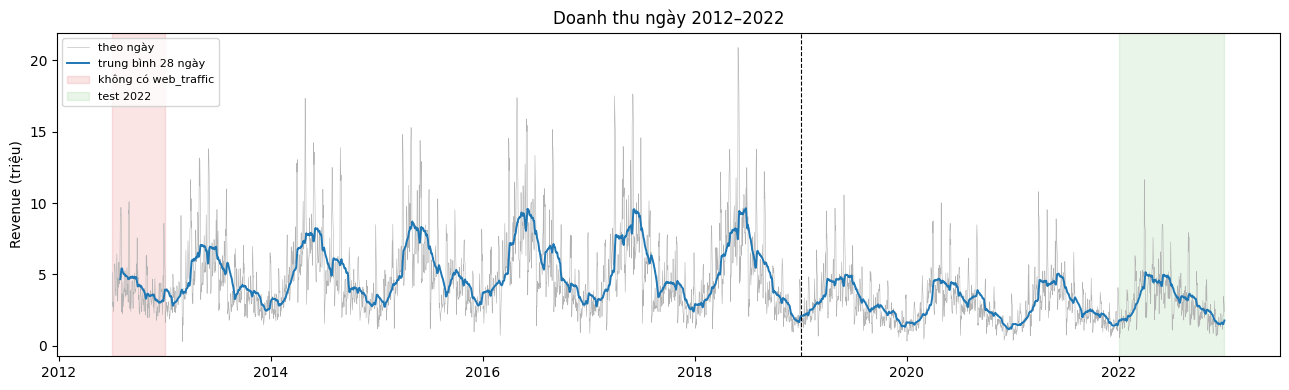

In [8]:
yearly = s['Revenue'].groupby(s.index.year).mean().rename('TB_ngay').to_frame()
yearly['so_voi_nam_truoc_%'] = (yearly['TB_ngay'].pct_change() * 100).round(1)
display(yearly.round({'TB_ngay': 0}))

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(s.index, s['Revenue'] / 1e6, lw=0.4, color='0.7', label='theo ngày')
ax.plot(s.index, s['Revenue'].rolling(28).mean() / 1e6, lw=1.4, color='C0', label='trung bình 28 ngày')
ax.axvspan(pd.Timestamp('2012-07-04'), pd.Timestamp('2012-12-31'), color='C3', alpha=0.12, label='không có web_traffic')
ax.axvspan(pd.Timestamp('2022-01-01'), s.index.max(), color='C2', alpha=0.10, label='test 2022')
ax.axvline(pd.Timestamp('2019-01-01'), color='k', ls='--', lw=0.8)
ax.set_ylabel('Revenue (triệu)')
ax.set_title('Doanh thu ngày 2012–2022')
ax.legend(loc='upper left', fontsize=8)
plt.tight_layout(); plt.show()

**Nhận xét**

- `sales` chạy từ 04/07/2012 (thứ 4) đến 31/12/2022 (thứ 7): **3.833 ngày, không thiếu ngày nào**. Năm 2022 đủ 12 tháng, nên dùng làm test được.
- Gom theo tuần thứ 2–chủ nhật được 548 tuần. Bỏ tuần đầu (5 ngày) và tuần cuối 26–31/12/2022 (6 ngày, thiếu chủ nhật) thì còn **546 tuần đủ ngày**, tức khoảng 546 × 4 = 2.184 mẫu cho PA1.
- Với horizon 4 tuần và mốc cắt vào mỗi chủ nhật:
  - 2022 (test) có **49 mốc cắt**, từ 26/12/2021 đến 27/11/2022;
  - 2021 (validation) cũng có 49 mốc.
- Tuần gán theo ngày chủ nhật kết thúc tuần. Ví dụ tuần 27/12/2021–02/01/2022 thuộc năm 2022.
- Doanh thu trung bình ngày giảm 38,6% vào năm 2019 (từ khoảng 5,07 xuống 3,11 triệu) và đến 2022 vẫn chưa hồi phục.
- Dữ liệu không có năm 2023. Giai đoạn 2023–2024 trong `sample_submission` là phần cuộc thi tự chấm.

## 5. Bảng inventory (ô Chất lượng, bảng 1.1)

Xem tần suất snapshot, cách tính các cột hết hàng, con số 67,3% và khả năng rò rỉ dữ liệu khi dùng inventory làm đặc trưng.

In [9]:
per_period = inv.groupby('snapshot_date').size()
print('Snapshot rơi vào ngày cuối tháng:', inv['snapshot_date'].eq(inv['snapshot_date'] + pd.offsets.MonthEnd(0)).mean())
print(f"Số kỳ: {inv['snapshot_date'].nunique()} ({inv['snapshot_date'].min().date()} → {inv['snapshot_date'].max().date()}),"
      f" mỗi kỳ {per_period.min()}–{per_period.max()} SKU")
print('Số kỳ mỗi SKU:', inv.groupby('product_id').size().describe()[['min', '50%', 'max']].to_dict())
print()
print('stockout_flag = 1:', round(inv['stockout_flag'].mean() * 100, 2), '%',
      '| trùng với stockout_days > 0:', (inv['stockout_flag'] == inv['stockout_days'].gt(0)).all())
print('overstock_flag = 1:', round(inv['overstock_flag'].mean() * 100, 2), '%',
      '| trùng với days_of_supply > 90:', (inv['overstock_flag'] == inv['days_of_supply'].gt(90)).all())
print('reorder_flag nhận các giá trị:', inv['reorder_flag'].unique())
approx = 1 - inv['stockout_days'] / inv['snapshot_date'].dt.days_in_month
print('corr(fill_rate, 1 - stockout_days/số ngày trong tháng):', round(np.corrcoef(inv['fill_rate'], approx)[0, 1], 4))
prev = inv_sorted.groupby('product_id')['stock_on_hand'].shift()
flow = (prev + inv_sorted['units_received'] - inv_sorted['units_sold'] == inv_sorted['stock_on_hand'])[prev.notna()]
print('Tồn cuối = tồn đầu + nhập - bán:', flow.mean())
print('\nstockout_days:', inv['stockout_days'].value_counts().sort_index().head(6).to_dict())

Snapshot rơi vào ngày cuối tháng: 1.0
Số kỳ: 126 (2012-07-31 → 2022-12-31), mỗi kỳ 376–562 SKU
Số kỳ mỗi SKU: {'min': 1.0, '50%': 27.0, 'max': 126.0}

stockout_flag = 1: 67.34 % | trùng với stockout_days > 0: True
overstock_flag = 1: 76.26 % | trùng với days_of_supply > 90: True
reorder_flag nhận các giá trị: [0]
corr(fill_rate, 1 - stockout_days/số ngày trong tháng): 0.9995
Tồn cuối = tồn đầu + nhập - bán: 1.0

stockout_days: {0: 19676, 1: 19654, 2: 19658, 3: 237, 4: 174, 5: 124}


corr với lượng bán cùng tháng: 0.990 | tháng trước: 0.830
units_sold / lượng bán cùng tháng (trung vị): 0.286


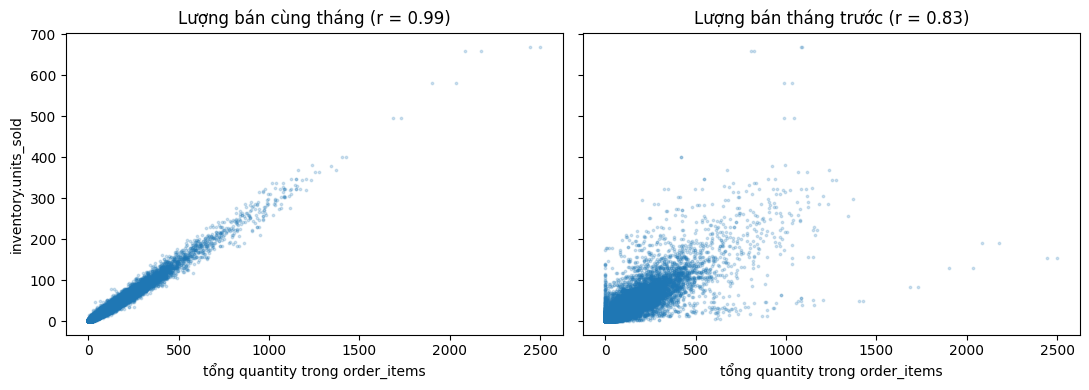

In [10]:
# units_sold của snapshot tháng M khớp với lượng bán tháng M hay tháng M-1?
q_prev = q_month.rename('qty_prev_month').reset_index()
q_prev['snapshot_date'] += pd.offsets.MonthEnd(1)
lk = inv_q.join(q_prev.set_index(['product_id', 'snapshot_date'])['qty_prev_month'],
                on=['product_id', 'snapshot_date']).fillna({'qty_prev_month': 0})
r_same = lk['units_sold'].corr(lk['qty_month'])
r_prev = lk['units_sold'].corr(lk['qty_prev_month'])
print(f'corr với lượng bán cùng tháng: {r_same:.3f} | tháng trước: {r_prev:.3f}')
print('units_sold / lượng bán cùng tháng (trung vị):', round((lk['units_sold'] / lk['qty_month'].replace(0, np.nan)).median(), 3))

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, col, r, name in [(axes[0], 'qty_month', r_same, 'cùng tháng'), (axes[1], 'qty_prev_month', r_prev, 'tháng trước')]:
    ax.scatter(lk[col], lk['units_sold'], s=3, alpha=0.2)
    ax.set_title(f'Lượng bán {name} (r = {r:.2f})')
    ax.set_xlabel('tổng quantity trong order_items')
axes[0].set_ylabel('inventory.units_sold')
plt.tight_layout(); plt.show()

In [11]:
# doanh thu mất do hết hàng: so hai cách quy đổi
oi_m['rev'] = oi_m['quantity'] * oi_m['unit_price']
rev_month = oi_m.groupby(['product_id', 'snapshot_date'])['rev'].sum().rename('rev_month')
x = inv.join(rev_month, on=['product_id', 'snapshot_date']).fillna({'rev_month': 0})
x = x.join(oi.groupby('product_id')['unit_price'].mean().rename('avg_price'), on='product_id')
lost_units = x['units_sold'] / x['fill_rate'] - x['units_sold']
print(f"units_sold x giá trung bình: {(lost_units * x['avg_price']).sum() / 1e6:,.1f} triệu")
print(f"doanh thu order_items x (1/fill_rate - 1): {(x['rev_month'] * (1 / x['fill_rate'] - 1)).sum() / 1e6:,.1f} triệu")

units_sold x giá trung bình: 428.5 triệu
doanh thu order_items x (1/fill_rate - 1): 1,448.8 triệu


**Nhận xét**

- Snapshot được chụp **mỗi tháng một lần, vào ngày cuối tháng**: 126 kỳ từ 07/2012 đến 12/2022, mỗi kỳ có 376–562 SKU. Ở bảng 1.1, mỗi dòng là "1 SKU tại 1 kỳ cuối tháng".
- **67,3%** là tỷ lệ snapshot có `stockout_flag = 1`, tức là trong tháng đó SKU hết hàng ít nhất 1 ngày. Tỷ lệ cao nhưng mỗi lần hết hàng chỉ ngắn: `stockout_days` gần như chỉ nhận ba giá trị 0, 1, 2 với tỷ lệ ngang nhau, và `fill_rate` trung bình là 0,96.
- Cách các cột được tính:
  - `stockout_flag` = `stockout_days > 0`;
  - `overstock_flag` = `days_of_supply > 90`;
  - `fill_rate` ≈ 1 − `stockout_days` / số ngày trong tháng;
  - tồn cuối = tồn đầu + nhập − bán, đúng ở mọi dòng.
- Các cột thừa:
  - `reorder_flag` luôn bằng 0, nên bỏ;
  - `product_name`, `category`, `segment`, `year`, `month` chỉ lặp lại thông tin đã có ở `products` và `snapshot_date`.
- **Rò rỉ dữ liệu.** `units_sold` của snapshot tháng M khớp với lượng bán của chính tháng M (r = 0,99; với tháng trước chỉ r = 0,83). Nghĩa là snapshot cuối tháng tổng hợp lại cả tháng vừa qua.
  - Khi làm đặc trưng, tại mốc cắt t chỉ lấy snapshot có `snapshot_date <= t` (dùng `pd.merge_asof(..., direction='backward')`).
  - Không join theo (năm, tháng) của tuần cần dự báo.
- **`units_sold` không cùng thang đo với `order_items`.** Nó chỉ bằng khoảng 0,29 lần số lượng bán thật. Vì vậy, nếu ước tính doanh thu mất do hết hàng bằng `units_sold × giá` thì chỉ ra khoảng 429 triệu, còn tính từ doanh thu `order_items` thì ra khoảng 1.449 triệu, gấp khoảng 3,4 lần.

## 6. SKU giá dưới 100 (ô Chất lượng, mục 1.3)

SKU giá < 100: 654 (27.1%)


,n,gia_min,gia_tv,gia_max,cogs_ratio_min,cogs_ratio_max,co_ban,co_ton_kho
low_price,,,,,,,,
False,1758,113.47,5606.06,40950.0,0.50,0.95,1598,1624
True,654,9.06,33.22,98.3,0.55,0.65,0,0


Trung vị giá: tất cả SKU = 4400 | SKU có bán = 5505
Tên có cả hai loại giá: 63 | giá cao / giá thấp: 67 → 960 lần


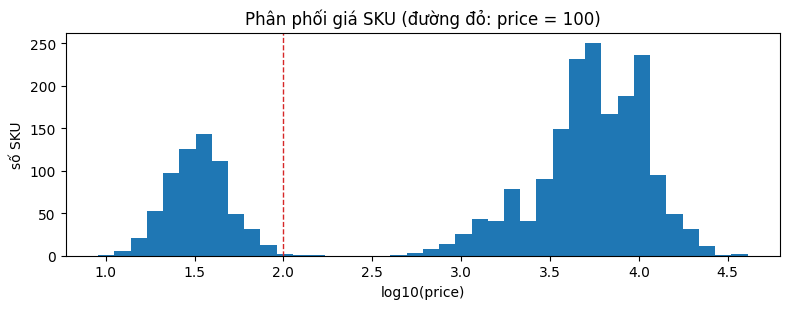

In [12]:
prod['low_price'] = prod['price'] < 100
prod['sold'] = prod['product_id'].isin(oi['product_id'])
prod['in_inventory'] = prod['product_id'].isin(inv['product_id'])
prod['cogs_ratio'] = prod['cogs'] / prod['price']

print(f"SKU giá < 100: {prod['low_price'].sum()} ({prod['low_price'].mean() * 100:.1f}%)")
display(prod.groupby('low_price').agg(n=('price', 'size'), gia_min=('price', 'min'), gia_tv=('price', 'median'),
                                      gia_max=('price', 'max'), cogs_ratio_min=('cogs_ratio', 'min'),
                                      cogs_ratio_max=('cogs_ratio', 'max'), co_ban=('sold', 'sum'),
                                      co_ton_kho=('in_inventory', 'sum')).round(2))
print('Trung vị giá: tất cả SKU =', round(prod['price'].median()), '| SKU có bán =', round(prod.loc[prod['sold'], 'price'].median()))

# cùng product_name, một SKU giá thấp và một SKU giá thường: tỷ lệ giá có cố định không?
pairs = prod.groupby('product_name').filter(lambda d: d['low_price'].any() and (~d['low_price']).any())
ratio = pairs.groupby('product_name')['price'].agg(lambda x: x.max() / x.min())
print(f'Tên có cả hai loại giá: {ratio.size} | giá cao / giá thấp: {ratio.min():.0f} → {ratio.max():.0f} lần')

fig, ax = plt.subplots(figsize=(8, 3.2))
ax.hist(np.log10(prod['price']), bins=40)
ax.axvline(2, color='C3', ls='--', lw=1)
ax.set_xlabel('log10(price)'); ax.set_ylabel('số SKU'); ax.set_title('Phân phối giá SKU (đường đỏ: price = 100)')
plt.tight_layout(); plt.show()

**Nhận xét**

- 654 SKU (27,1%) có giá 9–98. Phân phối `log10(price)` tách thành hai cụm rõ rệt.
- Nhóm này **không phải lỗi đơn vị**:
  - Nếu là lỗi đơn vị, SKU cùng tên sẽ lệch giá theo một hệ số cố định (như 100 hay 1.000). Thực tế hệ số dao động từ 67 đến 960 lần.
  - `cogs/price` của nhóm này nằm gọn trong khoảng 0,55–0,65, còn nhóm thường trải từ 0,50 đến 0,95.
  - Cả 654 SKU **chưa từng được bán** và **không có trong inventory**.
- Đây là SKU không hoạt động, **không ảnh hưởng đến nhãn PA1**.
- Số SKU thực sự hoạt động là 1.598 (có bán). Trung vị giá của nhóm này là khoảng 5.505, không phải 4.400.

## 7. Đơn vị tiền tệ (ô Chất lượng, mục 1.3)

In [13]:
print('Giá trị đơn: TB', round(order_total.mean()), '| trung vị', round(order_total.median()))
print('unit_price: trung vị', round(oi['unit_price'].median()), '| min', round(oi['unit_price'].min()), '| max', round(oi['unit_price'].max()))
print('shipping_fee: trung vị', dfs['shipments']['shipping_fee'].median(), '| max', dfs['shipments']['shipping_fee'].max())
print('Revenue ngày: trung vị', round(s['Revenue'].median()))
print('min_order_value của khuyến mãi:', sorted(dfs['promotions']['min_order_value'].unique().tolist()))

Giá trị đơn: TB 24238 | trung vị 17229
unit_price: trung vị 4258 | min 393 | max 43056
shipping_fee: trung vị 1.73 | max 32.0
Revenue ngày: trung vị 3647304
min_order_value của khuyến mãi: [0, 50000, 100000, 150000, 200000]


**Nhận xét**

- Dữ liệu không có cột nào ghi đơn vị tiền, và chưa có thông tin chính thức từ BTC. Vì vậy notebook giữ số theo đơn vị gốc; biểu đồ chỉ ghi "triệu", không ghi VNĐ.
- Các con số khớp nhau về mặt nội bộ: giá trị đơn trung bình khoảng 24.000, `payment_value` bằng đúng tổng tiền hàng.
- `shipping_fee` (trung vị 1,73) lệch thang đo so với giá hàng, và không được cộng vào `payment_value`.
- WMAPE không phụ thuộc đơn vị, nên việc này không ảnh hưởng đến đánh giá mô hình.

## 8. Tóm tắt

**Ô Chất lượng**

> Không có dòng trùng; 16 dòng `order_items` trùng (order_id, product_id) là hai dòng hàng riêng, giữ nguyên. Ô rỗng chỉ ở 3 cột mang nghĩa "không áp dụng" (promo_id 61,3%, promo_id_2 99,97%, applicable_category 80%). Thiếu thật: traffic thiếu 181 ngày nửa cuối 2012 (04/07–31/12); 564 đơn đã gửi (0,1%) không có vận đơn; inventory chỉ có 1.624/2.412 SKU. Mâu thuẫn: 73,8% đơn đặt trước ngày tạo tài khoản; 18,6% dòng hàng (133.052) bán dưới giá vốn; 50,6% snapshot vừa hết hàng vừa tồn dư. 654 SKU (27,1%) giá < 100 không phải lỗi đơn vị mà là SKU không hoạt động (chưa từng bán, không có tồn kho), không ảnh hưởng nhãn. Đơn vị tiền tệ: chưa có thông tin chính thức.

**Ô Thời gian**

> Theo ngày, 04/07/2012 – 31/12/2022, 3.833 ngày, không thiếu ngày; năm 2022 đủ 12 tháng. Theo tuần T2–CN: 546 tuần đủ ngày (bỏ tuần đầu 5 ngày và tuần cuối 6 ngày). Doanh thu trung bình ngày giảm khoảng 39% từ 2019 và chưa hồi phục.

**Số liệu trong bản đề xuất cần cập nhật**

- Bảng 1.1:
  - inventory: "1 SKU tại 1 kỳ snapshot cuối tháng (126 kỳ, 07/2012–12/2022)";
  - order_items: "1 dòng hàng trong 1 đơn".
- Bảng 1.2, ô Quy mô: sales có 3.833 ngày; promotions 50 dòng; shipments 566.067 dòng.
- Bảng 1.2, ô Chất lượng: "181 ngày đầu 2012" sửa thành "181 ngày nửa cuối 2012".
- Mục 1.3: trung vị giá của SKU có bán là khoảng 5.505.
- Bảng 4.1, PA1, ô (2): khoảng 546 tuần × 4 danh mục ≈ 2.184 mẫu.

**Lưu ý khi làm đặc trưng và chia tập**

- Validation 2021 và test 2022 mỗi năm có 49 mốc cắt. Bỏ tuần lẻ cuối cùng. Tuần gán theo ngày chủ nhật kết thúc tuần.
- Inventory join theo `snapshot_date <= mốc cắt` (merge_asof). Bỏ `reorder_flag`.
- `inventory.units_sold` chỉ bằng khoảng 0,29 lần số lượng trong `order_items`. Khi ước tính doanh thu mất do hết hàng, lấy doanh thu từ `order_items` nhân với (1/`fill_rate` − 1). Theo cách này, doanh thu mất khoảng 1.449 triệu (xem mục 5).